# Fitting Real Data

**What problem this solves.** Every astronomer's first question on picking up a new SED code
is *how do I fit my own data?* — not a synthetic mock, not the tutorial's prebuilt sample,
but a FITS spectrum they already have on disk. This notebook walks that path end-to-end:
wavelength grid, noise vector, redshift, masking, calibration, and an inference call.

**What you'll see.** A synthetic "SDSS-like" optical spectrum (built here so the notebook
runs with no external data dependency) fitted with `Fitter.run("vi", ...)`, with
residuals, posterior corner, and SFH recovery. At the end, a reference block shows the
exact edits needed to swap the synthetic data for a real FITS file.

**Why tengri is different.** The full chain — wavelength response, noise, calibration,
spectral line masking — is a single pure-JAX function. Gradients flow through every step,
so swapping your FITS loader in does not break the inference path.

> ⚠ **This notebook is a workflow sketch.** The "observed" spectrum here is synthesised
> from a known truth so the recovery diagnostics are meaningful. Production work needs a
> real noise model, calibration systematics, and emission-line treatment.

**Prereqs:** [`00_quickstart.py`](00_quickstart.py), [`08_fitting_spectra.py`](08_fitting_spectra.py).
**Continue with:** [`14_joint_photometry_spectroscopy.py`](14_joint_photometry_spectroscopy.py),
[`15_emission_line_measurements.py`](15_emission_line_measurements.py).

In [1]:
import os
import sys
import time
import warnings

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))
except NameError:
    _nb_dir = os.getcwd()
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))

_src = os.path.join(_repo_root, "src")
if os.path.isdir(os.path.join(_src, "tengri")):
    sys.path.insert(0, _src)
sys.path.insert(0, _repo_root)
sys.path.insert(0, _nb_dir)

import importlib.util

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.45")

from tengri import (
    Fitter,
    Fixed,
    SEDModel,
    Observation,
    Parameters,
    Photometry,
    Spectroscopy,
    Uniform,
    load_ssp_data,
)

_repo_data_root = None
_spec_tengri = importlib.util.find_spec("tengri")
if _spec_tengri is not None and _spec_tengri.origin:
    _walk = os.path.dirname(os.path.abspath(_spec_tengri.origin))
    for _step in range(12):
        _candidate = os.path.join(_walk, "notebooks", "_plot_style.py")
        if os.path.isfile(_candidate):
            sys.path.insert(0, os.path.dirname(_candidate))
            _repo_data_root = os.path.dirname(os.path.dirname(os.path.abspath(_candidate)))
            break
        _parent_walk = os.path.dirname(_walk)
        if _parent_walk == _walk:
            break
        _walk = _parent_walk

if _repo_data_root is None:
    _np_here = os.path.abspath(os.getcwd())
    while True:
        if os.path.isfile(os.path.join(_np_here, "_plot_style.py")):
            sys.path.insert(0, _np_here)
            _repo_data_root = os.path.dirname(_np_here)
            break
        _ppt = os.path.join(_np_here, "notebooks", "_plot_style.py")
        if os.path.isfile(_ppt):
            _nbsd = os.path.dirname(_ppt)
            sys.path.insert(0, _nbsd)
            _repo_data_root = os.path.dirname(_nbsd)
            break
        _parent_here = os.path.dirname(_np_here)
        if _parent_here == _np_here:
            break
        _np_here = _parent_here

if _repo_data_root is not None and os.path.isdir(os.path.join(_repo_data_root, "data")):
    os.chdir(_repo_data_root)
elif os.path.isdir(os.path.join(_repo_root, "data")):
    os.chdir(_repo_root)
elif os.path.isdir("data"):
    pass
elif os.path.isdir(os.path.join("..", "data")):
    os.chdir("..")

FIGDIR = os.path.join("notebooks", "figures", "real_data")
os.makedirs(FIGDIR, exist_ok=True)

from _plot_style import (
    COLORS,
    convergence_table,
    plot_sfh,
    safe_corner,
    setup_style,
)

setup_style()

W0422 23:09:40.986845 22765099 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


In [2]:
ssp_data = load_ssp_data("data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")

## Loading and Preparing Data

For this demo, we simulate "real" data by generating a mock with realistic
noise properties. Replace this cell with your own data loading code.

In [3]:
# Simulate "real" SDSS-like spectrum
# In practice: load from FITS file, trim wavelength, mask bad pixels
WAVE_OBS = jnp.linspace(3800.0, 9200.0, 200)
REDSHIFT = 0.05  # known spectroscopic redshift

obs = Observation(
    photometry=Photometry.from_names(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"]),
    spectroscopy=Spectroscopy(wave_obs=WAVE_OBS),
)

spec = Parameters(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
    sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 1.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(REDSHIFT),
    mean_sfh_type="tsnorm",
)
model = SEDModel(spec, ssp_data, observation=obs)

# Generate a "real" galaxy (in practice, load from file)
true_params = spec.sample(jax.random.PRNGKey(42))
# Override tsnorm to a typical star-forming galaxy (still forming stars now)
true_params = {**true_params}
true_params["sfh_tsnorm_log_peak_sfr"] = jnp.array(1.2)
true_params["sfh_tsnorm_peak_lbt_gyr"] = jnp.array(3.0)
true_params["sfh_tsnorm_width_gyr"] = jnp.array(3.0)
true_params["sfh_tsnorm_skew"] = jnp.array(0.3)
true_params["sfh_tsnorm_trunc"] = jnp.array(2.0)
mock = model.mock_spectrum(true_params, WAVE_OBS, snr=25.0, key=jax.random.PRNGKey(1))

# This is your data:
flux_obs = mock.flux_obs  # shape (200,)
noise = mock.noise  # shape (200,), per-pixel uncertainties

/Users/suchethacooray/Projects/tengri/src/tengri/forward/sed_model.py:517: BakedInNebularWarning: BakedInBackend: nebular emission is baked into the SSP file at a FIXED logU and FIXED escape fraction determined when the SSP grid was generated (commonly logU = −3, but depends on the SSP file). The ionization parameter and escape fraction are NOT free parameters — varying neb_logU or neb_fesc in your Parameters will have no effect. Check your SSP file's nebular assumptions. Switch to CloudyGridBackend or CueBackend to vary nebular properties. To suppress: pass ionizing_source_warning='suppress'.
  self._nebular_backend = BakedInBackend()


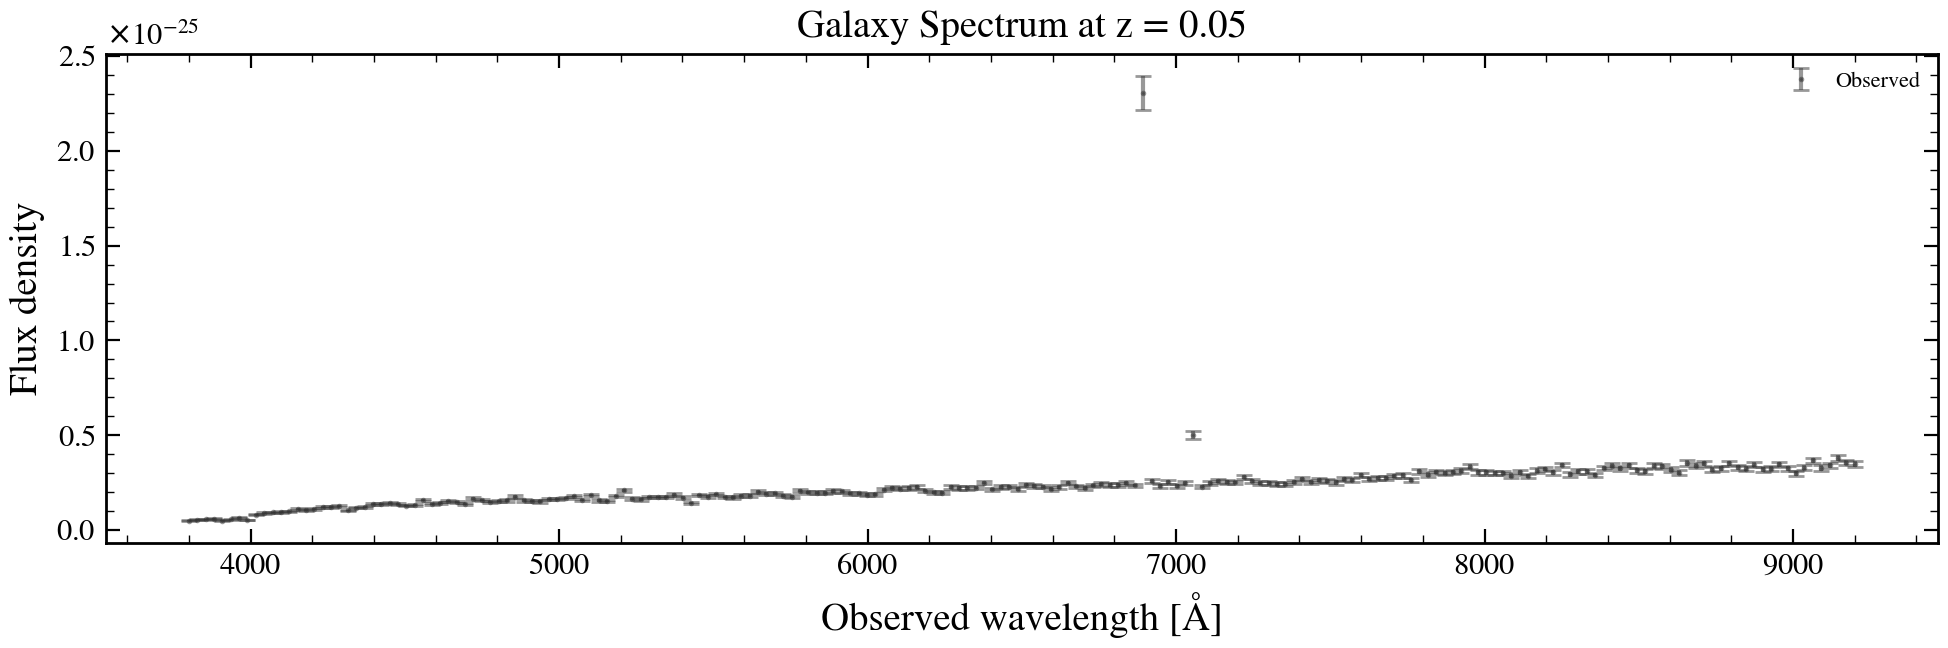

In [4]:
# --- FIGURE 1: "Real" spectrum ---
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.errorbar(
    np.array(WAVE_OBS),
    np.array(flux_obs),
    yerr=np.array(noise),
    fmt=".",
    ms=2,
    color=COLORS["data"],
    alpha=0.5,
    label="Observed",
)
ax.set_xlabel("Observed wavelength [Å]")
ax.set_ylabel("Flux density")
ax.set_title(f"Galaxy Spectrum at z = {REDSHIFT}")
ax.legend(fontsize=8)
fig.tight_layout()
# plt.savefig(os.path.join(FIGDIR, "fig01_real_spectrum.png"), dpi=150, bbox_inches="tight")
plt.show()

## Fitting

In [5]:
fitter = Fitter(model, flux_obs, noise, data_type="spectroscopy")

# MAP initialization
result_map = fitter.run("map", n_steps=500, verbose=False)

# Compile + run vi (geoVI) with timing separation
t0_c = time.perf_counter()
fitter.compile(verbose=False)
t_compile = time.perf_counter() - t0_c
t0 = time.perf_counter()
result = fitter.run(
    "vi",
    n_iterations=8,
    n_samples=4,
    n_posterior_samples=500,
    verbose=False,
)
t_run = time.perf_counter() - t0
print(f"XLA compile: {t_compile:.1f}s (one-time, cached)")
print(f"vi (geoVI): {t_run:.1f}s <- runtime per galaxy")

E0422 23:11:00.999696 22765090 slow_operation_alarm.cc:73] Constant folding an instruction is taking > 1s:

  %transpose.2519 = f64[93,5994,15]{2,1,0} transpose(%constant.57758), dimensions={1,2,0}, metadata={op_name="jit(run_evi_geovi)/vmap()/while/body/while/body/transpose(jvp(jit(interpolate_metallicity_smooth)))"}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
E0422 23:11:01.029473 22765074 slow_operation_alarm.cc:140] The operation took 1.034874s
Constant folding an instruction is taking > 1s:

  %transpose.2519 = f64[93,5994,15]{2,1,0} transpose(%constant.57758), dimensions={1,2,0}, metadata={op_name="jit(run_evi_geovi)/vmap()/while

E0422 23:11:38.204287 22765166 message_lite.cc:592] xla.cpu.CompilationResultProto exceeded maximum protobuf size of 2GB: 2719079522
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/jax/_src/compiler.py:834: UserWarning: Error writing persistent compilation cache entry for 'jit_run_evi_geovi': JaxRuntimeError: INTERNAL: PjRtCpuClient::SerializeExecutable proto serialization failed
  warnings.warn(


assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


...

MCG: Iteration 5 ⛰:-3.2980e-04 Δ⛰:7.5274e-05 ➽:3.5943e-04 |∇|:4.9211e-01 ➽:2.6906e-01


MCG: Iteration 6 ⛰:-5.1015e-04 Δ⛰:1.8035e-04 ➽:3.5943e-04 |∇|:2.3289e-01 ➽:2.6906e-01


M: →:1.0 ↺:False #∇²:18 |↘|:1.098990e-02 🞋:8.000000e-05
M: Iteration 3 ⛰:+2.118570e+02 Δ⛰:5.679611e-04 🞋:1.000000e-03


OPTIMIZE_KL: Iteration 0008 ⛰:+2.1186e+02
OPTIMIZE_KL: #(Nonlinear sampling steps) (3, 3, 3, 3, 3, 3, 3, 2)
OPTIMIZE_KL: #(KL minimization steps) 3
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     2.1±   0.035, avg:   +0.039±   0.059, #dof:    200'

OPTIMIZE_KL: Prior residual(s):
dust_tau_bc             :: 'reduced χ²:    0.12±     0.1, avg:    -0.15±    0.31, #dof:      1'
dust_tau_diff           :: 'reduced χ²:     1.2±    0.63, avg:     +1.0±    0.29, #dof:      1'
met_logzsol             :: 'reduced χ²:     5.2±     1.8, avg:     -2.3±    0.38, #dof:      1'
sfh_tsnorm_log_peak_sfr :: 'reduced χ²:    0.34±   0.074, avg:    +0.58±   0.063, #dof:      1'
sfh_tsnorm_peak_lbt_gyr :: 'reduced χ²:    0.52±    0.55, avg:     -0.3±    0.66, #dof:      1'
sfh_tsnorm_skew         :: 'reduced χ²:    0.04±   0.045, avg:   +0.061±    0.19, #dof:      1'
sfh_tsnorm_trunc        :: 'reduced χ²:     1.3±     1.4, avg:    -0.75±    0.85, #dof:      1'
sfh_tsnorm_width_gyr    :: 'reduced χ²:  

XLA compile: 175.4s (one-time, cached)
vi (geoVI): 71.3s <- runtime per galaxy


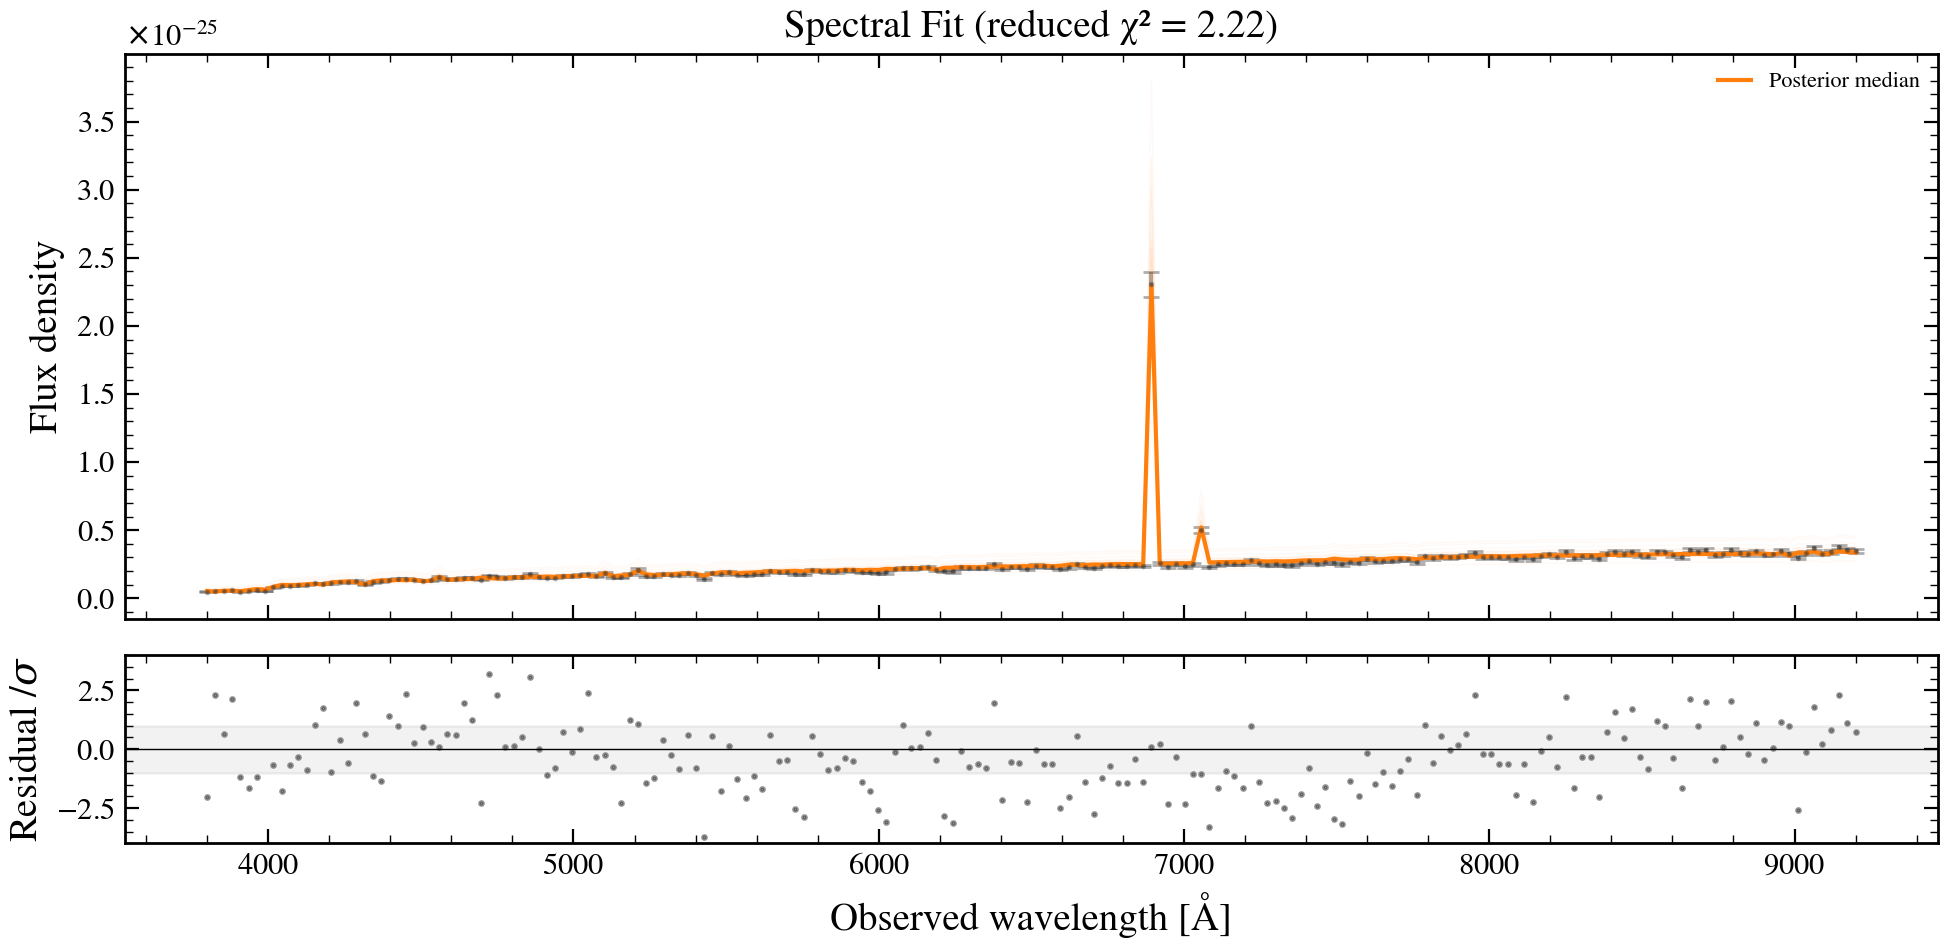

In [6]:
# --- FIGURE 2: Spectral fit ---
draws = []
for i in range(50):
    idx = i % len(result.samples[spec.free_params[0]])
    p = {k: v[idx] for k, v in result.samples.items()}
    draws.append(np.array(model.predict_spectrum(p)))
draws = np.array(draws)
med = np.median(draws, axis=0)

fig, (ax_f, ax_r) = plt.subplots(
    2, 1, figsize=(10, 5), gridspec_kw={"height_ratios": [3, 1]}, sharex=True
)
w = np.array(WAVE_OBS)
ax_f.errorbar(
    w, np.array(flux_obs), yerr=np.array(noise), fmt=".", ms=2, color=COLORS["data"], alpha=0.4
)
for d in draws[:30]:
    ax_f.plot(w, d, color=COLORS["vi"], alpha=0.04, lw=0.5)
ax_f.plot(w, med, color=COLORS["vi"], lw=1.5, label="Posterior median")
ax_f.legend(fontsize=8)
ax_f.set_ylabel("Flux density")

res = (np.array(flux_obs) - med) / np.array(noise)
ax_r.scatter(w, res, s=2, c=COLORS["data"], alpha=0.5)
ax_r.axhline(0, color="k", lw=0.5)
ax_r.axhspan(-1, 1, alpha=0.1, color="grey")
ax_r.set_ylim(-4, 4)
ax_r.set_ylabel(r"Residual /$\sigma$")
ax_r.set_xlabel("Observed wavelength [Å]")

chi2 = np.sum(res**2) / len(res)
ax_f.set_title(f"Spectral Fit (reduced χ² = {chi2:.2f})")
fig.tight_layout()
# plt.savefig(os.path.join(FIGDIR, "fig02_spectral_fit.png"), dpi=150, bbox_inches="tight")
plt.show()

In [7]:
convergence_table({"vi": result})

Method           ESS min  ESS med    τ max   Accept   Diverg     Status
-----------------------------------------------------------------------
vi                   240      303      2.1        —        —       WARN

Warnings:
  [vi] Median ESS = 303 < 400 target — consider more samples


{'vi': {'ess_min': 239.95605605197912,
  'ess_median': 303.0418719417619,
  'n_params_low_ess': 0,
  'tau_max_max': 2.117054298850275,
  'tau_max_median': 1.6763818443933955,
  'n_params_short_chain': 0,
  'converged': False,
  'warnings': ['Median ESS = 303 < 400 target — consider more samples']}}

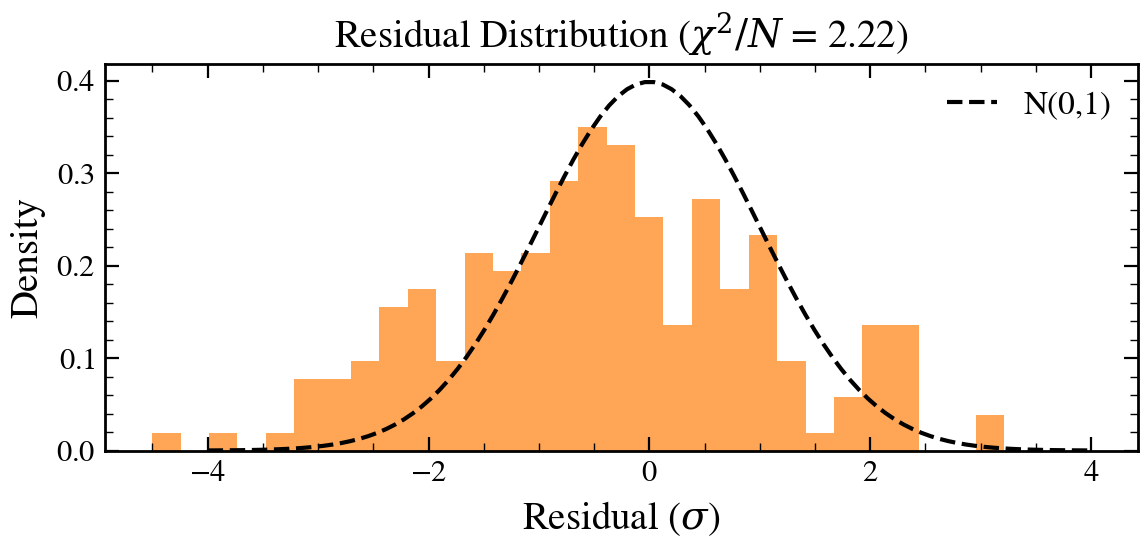

In [8]:
# --- Residual distribution (should be ~N(0,1) if model adequate) ---
residuals = (np.array(flux_obs) - med) / np.array(noise)
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(residuals, bins=30, density=True, alpha=0.7, color=COLORS["vi"])
x = np.linspace(-4, 4, 100)
ax.plot(x, np.exp(-(x**2) / 2) / np.sqrt(2 * np.pi), "k--", lw=1.5, label="N(0,1)")
ax.set_xlabel(r"Residual ($\sigma$)")
ax.set_ylabel("Density")
ax.legend()
chi2_dof = float(np.mean(residuals**2))
ax.set_title(f"Residual Distribution ($\\chi^2/N$ = {chi2_dof:.2f})")
fig.tight_layout()
# plt.savefig(os.path.join(FIGDIR, "fig02b_residual_hist.png"), dpi=150, bbox_inches="tight")
plt.show()

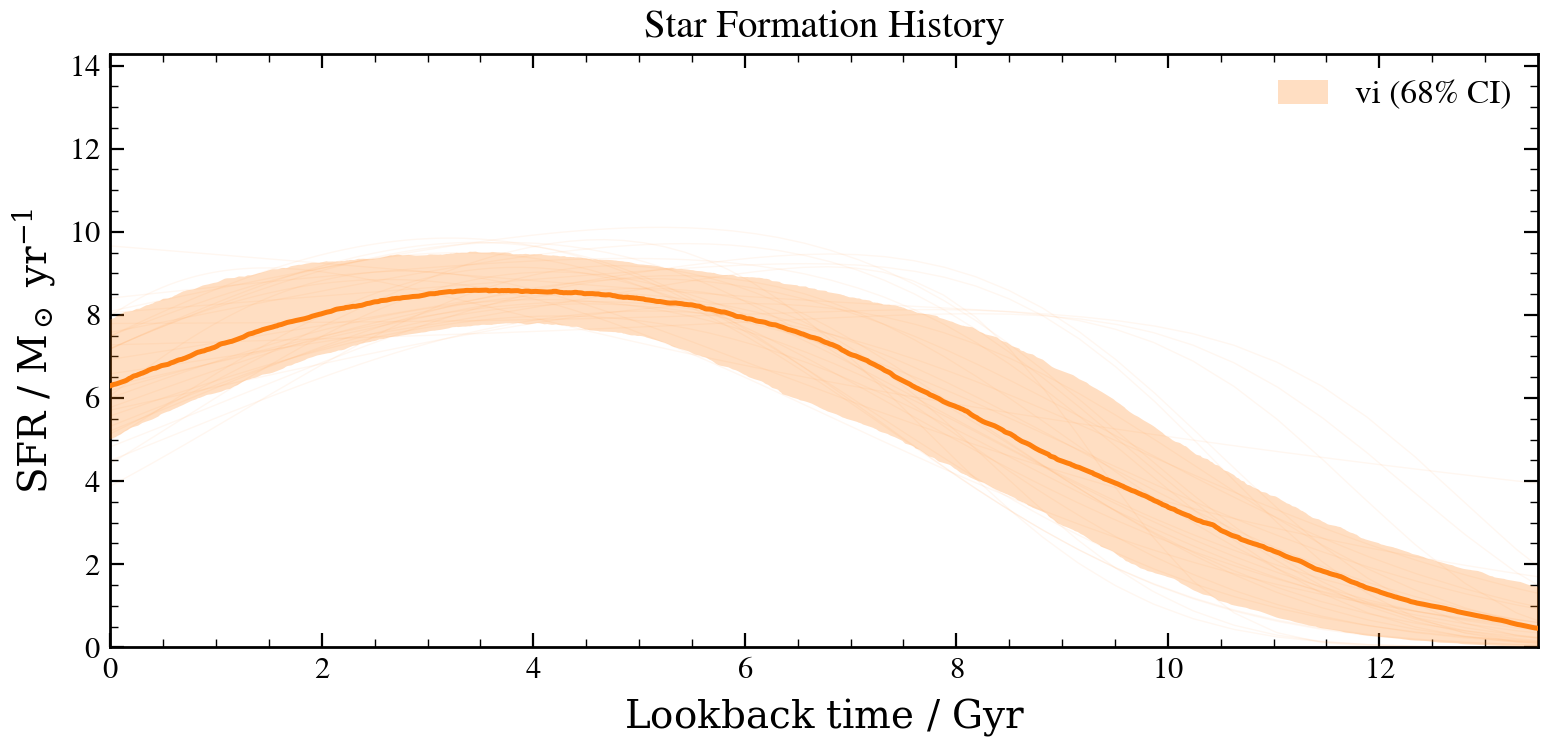

In [9]:
# --- FIGURE 3: SFH posterior ---
fig, ax = plt.subplots(figsize=(8, 4))
plot_sfh(model, result, ax=ax, color=COLORS["vi"], label="vi", method="geoVI")
ax.set_title("Star Formation History")
fig.tight_layout()
# plt.savefig(os.path.join(FIGDIR, "fig03_sfh.png"), dpi=150, bbox_inches="tight")
plt.show()

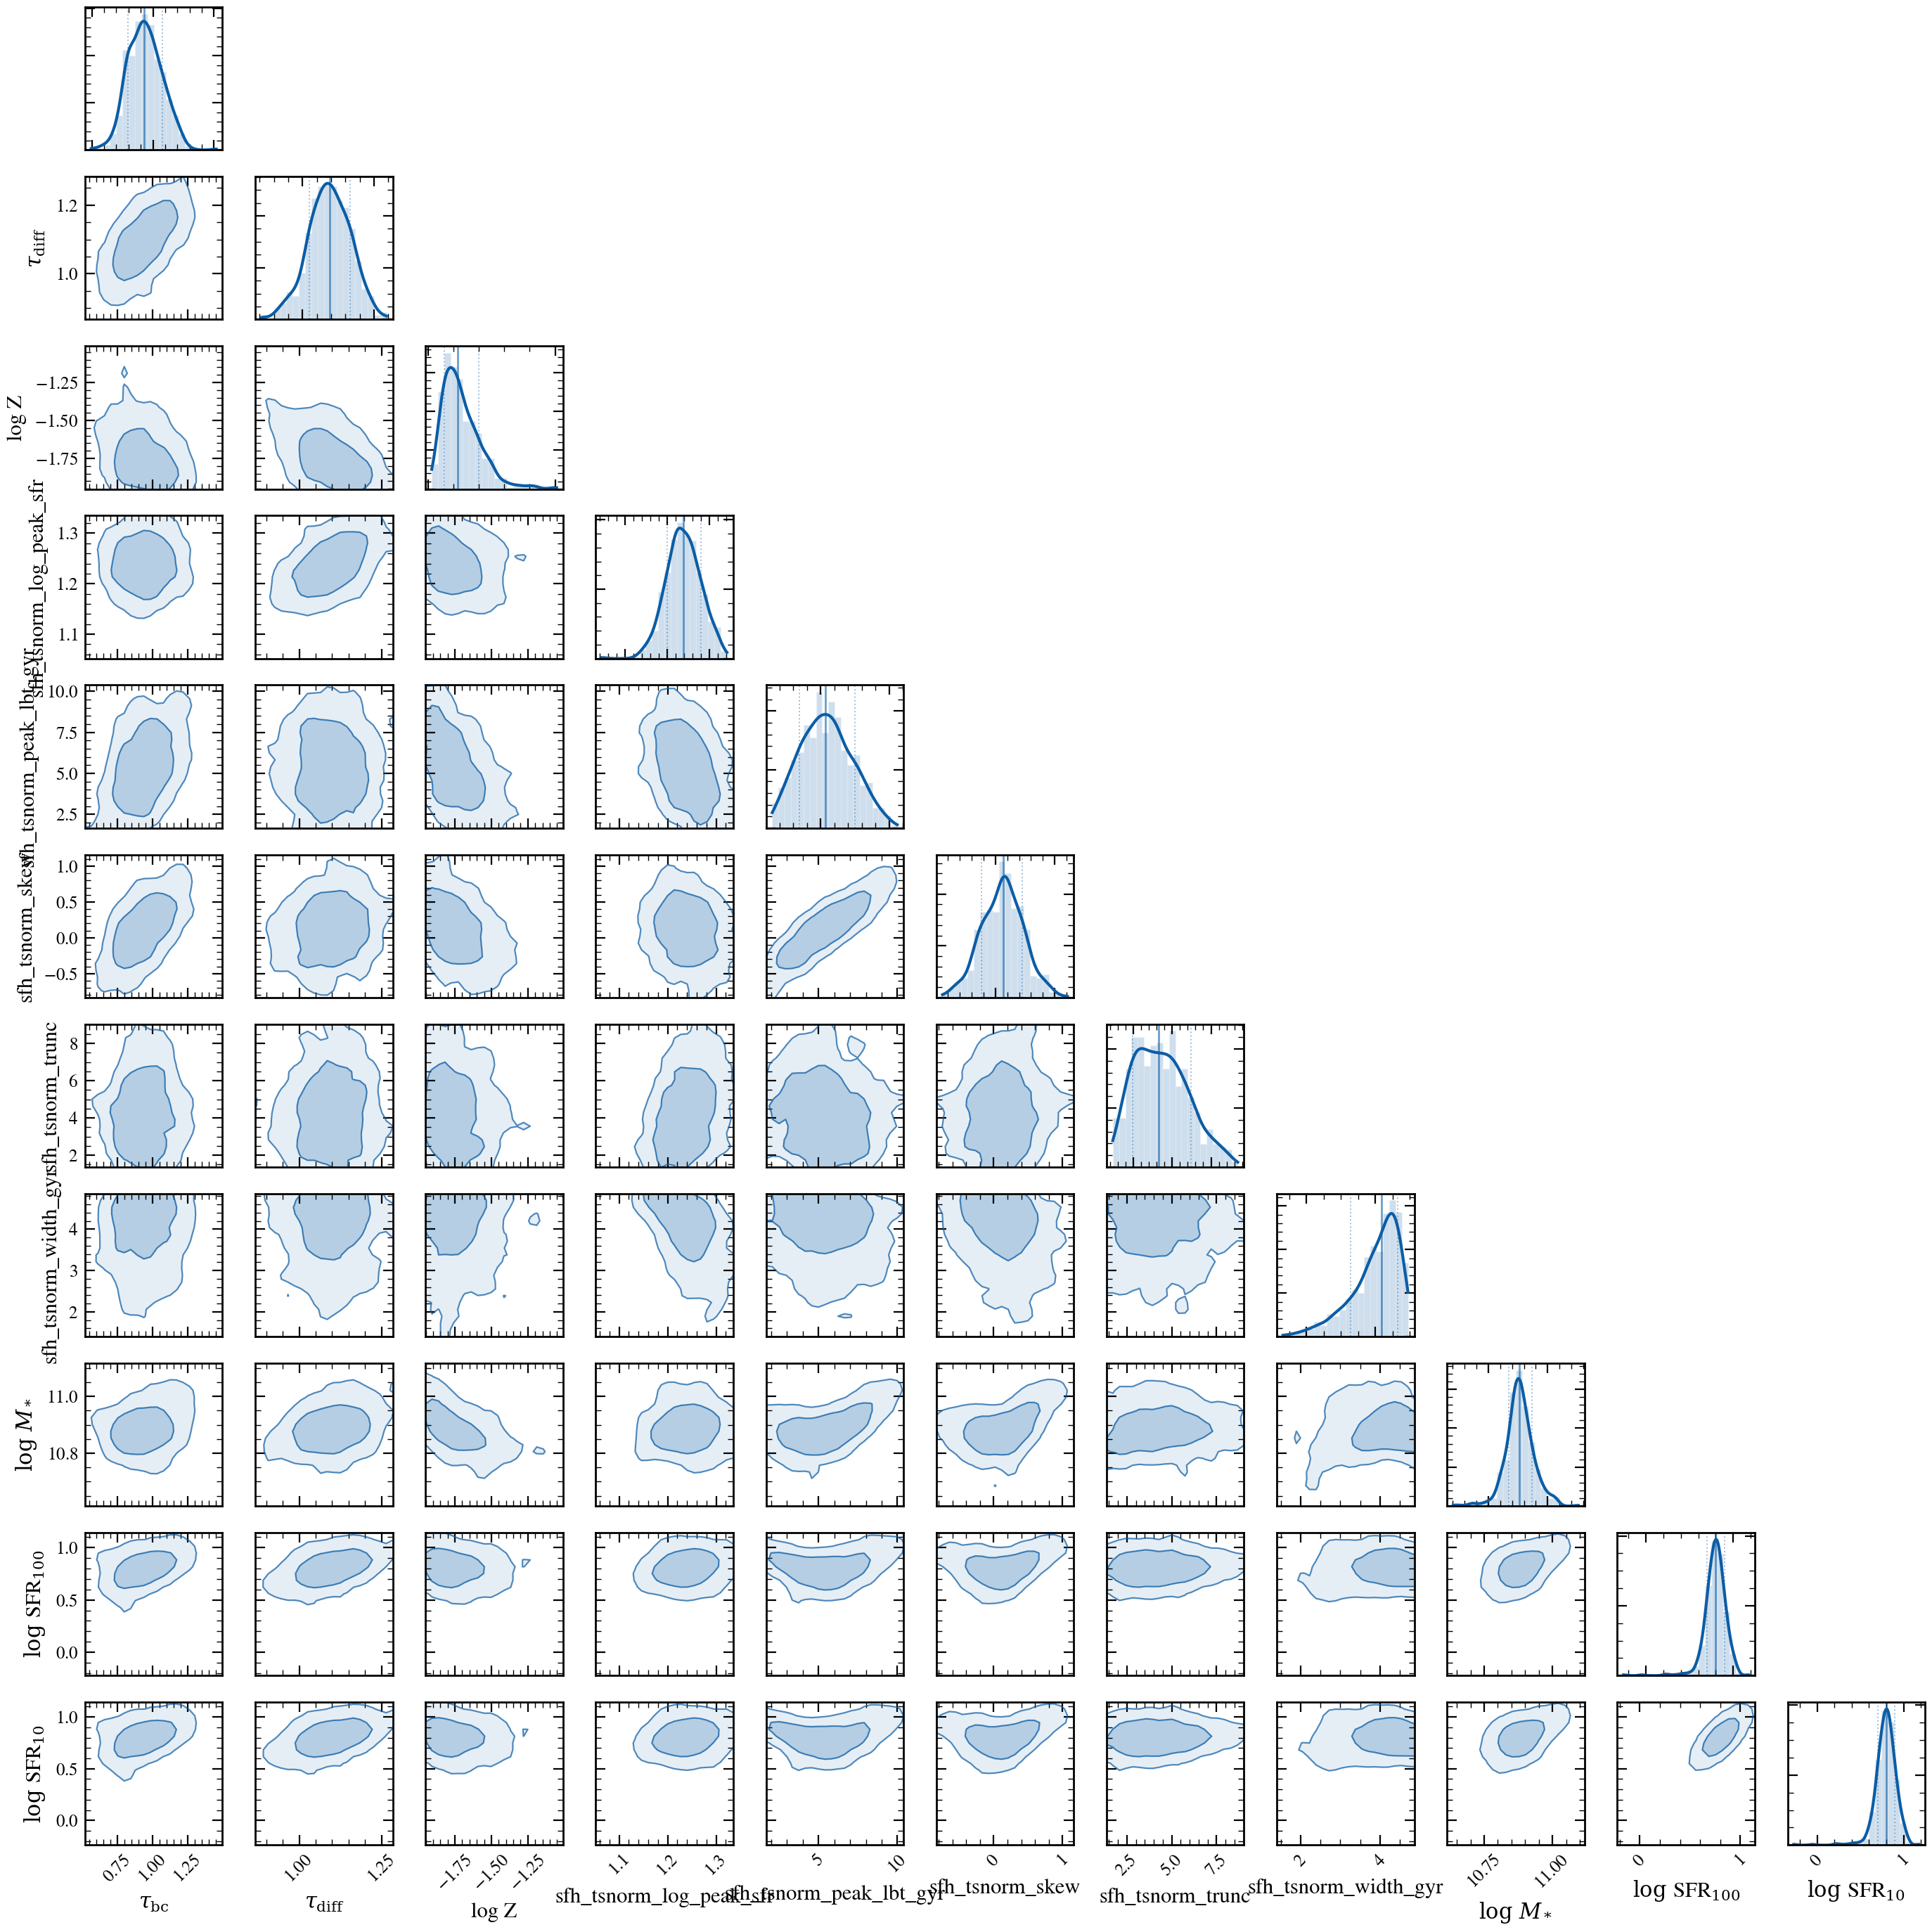

In [10]:
# --- FIGURE 4: Corner plot ---
fig = safe_corner(result)
if fig is not None:
    # plt.savefig(os.path.join(FIGDIR, "fig04_corner.png"), dpi=150, bbox_inches="tight")
    pass
plt.show()

### Practical considerations for real data

**Inverse variance → noise conversion:**
```python
ivar = hdu[1].data["ivar"]
good = (ivar > 0) & np.isfinite(ivar) & np.isfinite(flux)
noise = np.sqrt(1.0 / ivar[good])
```
Always guard against `ivar ≤ 0` (bad pixels, masked regions).

**Telluric absorption:** Mask 6860–6960 Å (B-band), 7580–7700 Å (A-band),
and 9300–9700 Å (water). These introduce systematic residuals if unmasked.

**Flux calibration floor:** Real spectra have ~5–10% calibration uncertainty
(standard star errors, slit losses). Consider adding a noise floor:
`noise_effective = np.sqrt(noise**2 + (0.05 * flux)**2)`.

**Wavelength calibration:** Typical ±1 Å residual for survey spectra (SDSS, DESI).
This propagates into velocity/redshift uncertainty of ±50 km/s at z ~ 0.

## Loading Your Own Data

Replace the mock generation with your data loader:

```python
from astropy.io import fits

hdu = fits.open("my_spectrum.fits")
wave_obs = hdu[1].data["wavelength"]  # observed-frame Angstrom
flux_obs = hdu[1].data["flux"]
ivar = hdu[1].data["ivar"]
good = (ivar > 0) & np.isfinite(ivar) & np.isfinite(flux_obs)
noise = np.sqrt(1.0 / ivar[good])
flux_obs, wave_obs = flux_obs[good], wave_obs[good]
```

Then proceed with `Model`, `Fitter`, and `vi` (geoVI) as above.

## Caveats

1. **Noise model**: Real data has wavelength-dependent systematics.
   Consider adding a calibration floor parameter via `NoiseModel` or
   the `noise_floor` argument to `Fitter`.
2. **Emission lines**: Strong emitters (e.g., Hα, [OIII]) may need line
   marginalization (set `eline_mode="marginalized"` in `Spectroscopy`)
   or masking via spectral windows.
3. **Resolution**: Convolve templates to match data spectral resolution
   using the `spectral_resolution` argument to `Spectroscopy`.
4. **Model adequacy**: Check residuals for systematic patterns.
   Use `result.validate()` for a short MCMC check.